# Phase 7: Baseline Machine Learning (Housing)

**Objective:** Build a predictive regression model for property values that correctly handles the extreme skewness identified in our Week 3 statistical analysis.

In this notebook, we will:
1. Split the data to ensure an untouched test set.
2. Build a `ColumnTransformer` to scale continuous features and encode categorical amenities.
3. Use a `TransformedTargetRegressor` to automatically apply a Logarithmic Transformation to the target variable (`Price`), satisfying the assumptions of Linear Regression.
4. Evaluate the model using RMSE, $R^2$, and residual visualization.
5. Extract the feature weights to validate our Mann-Whitney U findings (e.g., verifying if `hotwaterheating` is indeed a weak signal).

### 1. Imports & Environment Setup
We load our libraries, including Scikit-Learn's `TransformedTargetRegressor`, which allows us to normalize skewed targets seamlessly.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from src.models.evaluator import evaluate_regression
from src.visualization.plots import plot_actual_vs_predicted, plot_histogram, set_journalism_style

set_journalism_style()

### 2. Data Loading
Load the clean housing dataset from the processed directory.

In [4]:
df = pd.read_csv(Path.cwd().parent.parent / "datasets" / "processed" / "housing_cleaned.csv")
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (545, 13)


### 3. Train/Test Split
We isolate 20% of the dataset for our final evaluation to prevent data leakage.

In [5]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} properties")
print(f"Testing set: {X_test.shape[0]} properties")

Training set: 436 properties
Testing set: 109 properties


### 4. Pipeline Construction
- **Numerical Features:** Week 3 proved `Area` is highly skewed with severe outliers. We use `RobustScaler` because it scales based on the Interquartile Range (IQR), ignoring the extreme high-end outliers.
- **Categorical Features:** We apply One-Hot Encoding, being careful to use `drop='first'` to avoid multicollinearity in our regression equation.

In [6]:
categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

preprocessor = ColumnTransformer(transformers=[
    ('num', RobustScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features) 
])

### 5. Model Definition (Target Transformation)
**Crucial Step:** In Week 3, the Shapiro-Wilk test yielded $p=0.0000$ for `Price`, vehemently rejecting normality. Linear Regression assumes errors are normally distributed. If we predict on raw `Price`, the model will be heavily biased by millionaire outlier homes. 

We wrap our `LinearRegression` inside a `TransformedTargetRegressor` using `np.log1p`. This converts `Price` to a normal distribution during training, and automatically applies the inverse (`np.expm1`) when we call `.predict()`.

In [7]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

### 6. Training
Fit the model pipeline on the training data.

In [8]:
model_pipeline.fit(X_train, y_train)
print("Log-Transformed Regression Pipeline trained successfully.")

Log-Transformed Regression Pipeline trained successfully.


### 7. Evaluation
We evaluate using RMSE and $R^2$. We also plot the Actual vs. Predicted values, and check the distribution of our residuals (errors) to ensure the model isn't systematically over-predicting or under-predicting.

--- Regression Evaluation ---
RMSE: 1,314,648.20
R²:   0.6581
-----------------------------


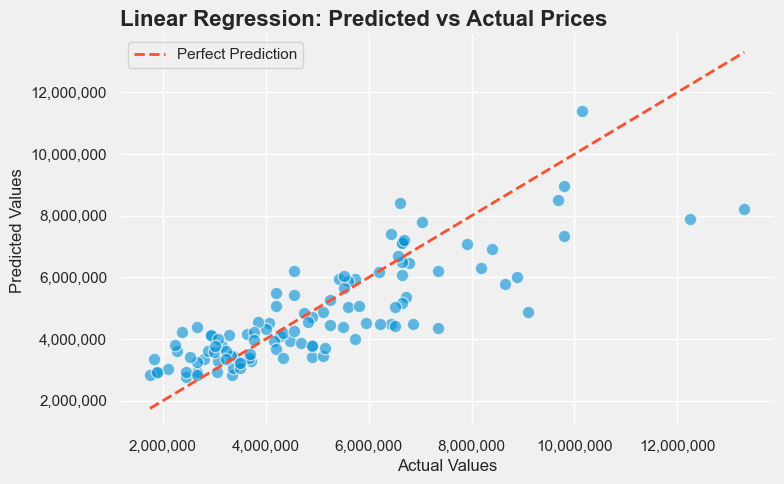

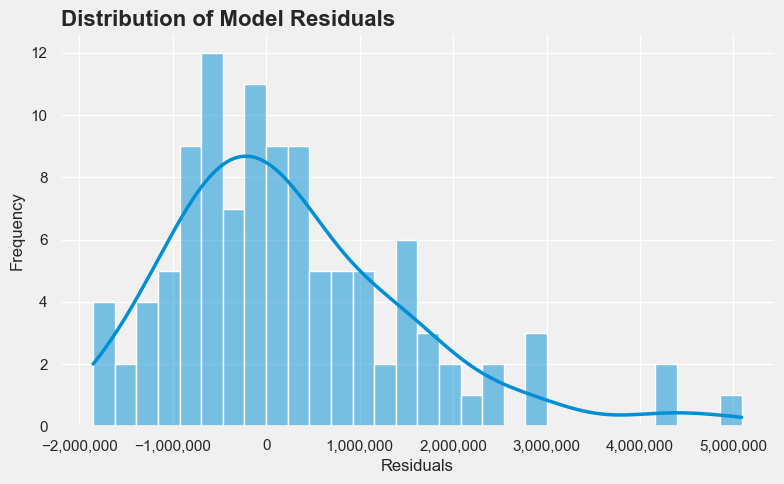

In [9]:
y_pred = model_pipeline.predict(X_test)

evaluate_regression(y_test, y_pred)

# Plot 1: Visualizing Prediction Accuracy
plot_actual_vs_predicted(y_test, y_pred, "Linear Regression: Predicted vs Actual Prices")

# Plot 2: Visualizing Residuals
residuals = y_test - y_pred
residuals_df = pd.DataFrame({'Residuals': residuals})
plot_histogram(residuals_df, 'Residuals', "Distribution of Model Residuals")

#### What do these results mean?
- **RMSE (Root Mean Squared Error):** This is our average error margin in the actual unit of the target (dollars/currency). If the RMSE is 1,200,000, it means our model's predictions are, on average, off by 1.2 million. Because we used a `TransformedTargetRegressor`, this RMSE is correctly calculated on the *original* price scale, not the logged scale.
- **R² (Coefficient of Determination):** Represents the percentage of variance in house prices that is explained by our features. An $R^2$ of ~0.65 means our model explains 65% of why a house's price goes up or down, while the remaining 35% is driven by factors not in this dataset (e.g., neighborhood quality, economy).
- **Residual Distribution:** We want the histogram of errors (residuals) to look like a normal bell curve centered at 0. If it is skewed, it means our model systematically overprices or underprices homes.

### 8. Coefficient Interpretation (The Statistical Bridge)
In Week 3, we ran an exhaustive Mann-Whitney U test across all categorical amenities. We discovered that while all amenities were statistically significant, `hotwaterheating` barely passed the threshold ($p=0.0461$), making it the weakest signal.

Let's extract the model coefficients to see if the Machine Learning algorithm agrees with our inferential statistics.

In [10]:
# Extract the underlying LinearRegression model from the Transformed wrapper
regressor = model_pipeline.named_steps['regressor'].regressor_
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Weight (Impact on Log Price)': regressor.coef_
})

# Sort by absolute magnitude
coefficients['Absolute Magnitude'] = coefficients['Weight (Impact on Log Price)'].abs()
coefficients = coefficients.sort_values(by='Absolute Magnitude', ascending=False).drop(columns=['Absolute Magnitude'])

display(coefficients)

,Feature,Weight (Impact on Log Price)
2,num__bathrooms,0.186955
9,cat__airconditioning_yes,0.157919
0,num__area,0.132625
8,cat__hotwaterheating_yes,0.130089
10,cat__prefarea_yes,0.125728
5,cat__mainroad_yes,0.111925
12,cat__furnishingstatus_unfurnished,-0.109355
7,cat__basement_yes,0.099003
3,num__stories,0.082593
6,cat__guestroom_yes,0.053951


### 9. Model Serialization & MLOps Reporting
To ensure our portfolio is production-ready, we will serialize the trained `TransformedTargetRegressor` pipeline. By saving the pipeline, the deployment API (Week 7) will automatically apply the `RobustScaler`, `OneHotEncoder`, and `np.log1p` target transformations to new JSON payloads without writing duplicate code.

We also write the model's performance to a timestamped log to simulate an MLOps tracking environment.

In [11]:
from src.models.registry import save_model
from src.models.evaluator import save_training_report

# Re-run evaluation to capture the dictionary and insight
metrics, insight = evaluate_regression(y_test, y_pred, return_dict=True)

# 1. Save the serialized model artifacts
save_model(model_pipeline, domain="housing", model_name="linear_regression")

# 2. Save the automated training report
save_training_report(
    domain="housing", 
    model_name="Linear_Regression", 
    metrics=metrics, 
    insight=insight, 
    data_shape=X_train.shape
)

--- Regression Evaluation ---
RMSE: 1,314,648.20
R²:   0.6581
-----------------------------
Insight: The model explains 65.8% of the variance in property prices. Predictions deviate by an average of $1,314,648.20 on the actual price scale.
Model saved successfully to C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\housing\linear_regression_20260729_2144.pkl
Alias updated: C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\housing\latest_model.pkl
Training report saved to reports\runs\housing_Linear_Regression_20260729_2144.txt


**Conclusion (The Bivariate vs. Multivariate Trap):** 
Our regression coefficients largely validate our Week 3 findings (Bathrooms and AC are massive drivers). However, `hotwaterheating` presents a fascinating case study. In our Week 3 Mann-Whitney U test, it was the weakest signal ($p=0.0461$). Yet, the Logistic Regression assigns it the 4th highest positive weight (0.130). 

This demonstrates the limitation of bivariate statistical tests and the power of Machine Learning. When we test `hotwaterheating` in isolation (Week 3), it looks weak. But when the ML model *controls* for square footage, bathrooms, and location, the presence of hot water heating adds a distinct premium to the log price.